# Baum-Welch Theory

From Wikipedia (https://en.wikipedia.org/wiki/Baum%E2%80%93Welch_algorithm): 

Baum–Welch algorithm is a special case of the expectation–maximization algorithm used to find the unknown parameters of a hidden Markov model (HMM).

It makes use of the forward-backward algorithm to compute the statistics for the expectation step

The Baum–Welch algorithm, the primary method for inference in hidden Markov models, is numerically unstable due to its recursive calculation of joint probabilities. As the number of variables grows, these joint probabilities become increasingly small, leading to the forward recursions rapidly approaching values below machine precision.

---

The Baum–Welch algorithm uses the well known EM algorithm to find the maximum likelihood estimate of the parameters of a hidden Markov model given a set of observed feature vectors.

Thus we can describe a hidden Markov model by $\theta = (A, B, \pi)$. The Baum–Welch algorithm finds a local maximum for:

$$\theta^* = \underset{\theta}{\arg\max} \ P(Y \mid \theta)$$

i.e. the HMM parameters $\theta$ that maximize the probability of the observations.

## Algorithm

Set $\theta = (A, B, \pi)$ with random initial conditions. They can also be set using prior information about the parameters if available; this can speed up the algorithm and steer it toward the desired local maximum.

### Forward Procedure

Let $\alpha_i(t) = P(Y_1 = y_1, \ldots, Y_t = y_t, X_t = i \mid \theta)$, the probability of seeing the observations $y_1, y_2, \ldots, y_t$ and being in state $i$ at time $t$. This is found recursively:

1. $\alpha_i(1) = \pi_i b_i(y_1)$
2. $\alpha_i(t+1) = b_i(y_{t+1}) \sum_{j=1}^{N} \alpha_j(t) a_{ji}$

Since this series converges exponentially to zero, the algorithm will numerically underflow for longer sequences. However, this can be avoided by scaling $\alpha$ in the forward procedure and $\beta$ in the backward procedure.

### Backward Procedure

Let $\beta_i(t) = P(Y_{t+1} = y_{t+1}, \ldots, Y_T = y_T \mid X_t = i, \theta)$, the probability of the ending partial sequence $y_{t+1}, \ldots, y_T$ given starting state $i$ at time $t$. We calculate $\beta_i(t)$ as:

1. $\beta_i(T) = 1$
2. $\beta_i(t) = \sum_{j=1}^{N} \beta_j(t+1) a_{ij} b_j(y_{t+1})$

### Update

We can now calculate the temporary variables. According to Bayes' theorem:

$$\gamma_i(t) = P(X_t = i \mid Y, \theta) = \frac{P(X_t = i, Y \mid \theta)}{P(Y \mid \theta)} = \frac{\alpha_i(t)\beta_i(t)}{\sum_{j=1}^{N} \alpha_j(t)\beta_j(t)}$$

which is the probability of being in state $i$ at time $t$ given the observed sequence $Y$ and the parameters $\theta$.

$$\xi_{ij}(t) = P(X_t = i, X_{t+1} = j \mid Y, \theta) = \frac{P(X_t = i, X_{t+1} = j, Y \mid \theta)}{P(Y \mid \theta)} = \frac{\alpha_i(t) a_{ij} \beta_j(t+1) b_j(y_{t+1})}{\sum_{k=1}^{N} \sum_{w=1}^{N} \alpha_k(t) a_{kw} \beta_w(t+1) b_w(y_{t+1})}$$

which is the probability of being in state $i$ and $j$ at times $t$ and $t+1$ respectively, given the observed sequence $Y$ and parameters $\theta$.

The denominators of $\gamma_i(t)$ and $\xi_{ij}(t)$ are the same; they represent the probability of making the observation $Y$ given the parameters $\theta$.

The parameters of the hidden Markov model $\theta$ can now be updated:

$$\pi_i^* = \gamma_i(1)$$

which is the expected frequency spent in state $i$ at time $1$.

$$a_{ij}^* = \frac{\sum_{t=1}^{T-1} \xi_{ij}(t)}{\sum_{t=1}^{T-1} \gamma_i(t)}$$

which is the expected number of transitions from state $i$ to state $j$ compared to the expected total number of transitions starting in state $i$, including from state $i$ to itself.

$$b_i^*(v_k) = \frac{\sum_{t=1}^{T} \mathbf{1}_{y_t = v_k} \gamma_i(t)}{\sum_{t=1}^{T} \gamma_i(t)}$$

where

$$\mathbf{1}_{y_t = v_k} = \begin{cases} 1 & \text{if } y_t = v_k \\ 0 & \text{otherwise} \end{cases}$$

is an indicator function, and $b_i^*(v_k)$ is the expected number of times the output observations have been equal to $v_k$ while in state $i$, over the expected total number of times in state $i$.

These steps are repeated iteratively until a desired level of convergence.

> **Note:** It is possible to over-fit a particular dataset, i.e. $P(Y \mid \theta_{\text{final}}) > P(Y \mid \theta_{\text{true}})$. The algorithm also does not guarantee a global maximum.

### Multiple Sequences

The algorithm described thus far assumes a single observed sequence $Y = y_1, \ldots, y_T$. However, in many situations there are several observed sequences $Y_1, \ldots, Y_R$. In this case, the information from all observed sequences must be used in the parameter updates. Assuming $\gamma_{ir}(t)$ and $\xi_{ijr}(t)$ have been computed for each sequence, the parameters are updated as:

$$\pi_i^* = \frac{\sum_{r=1}^{R} \gamma_{ir}(1)}{R}$$

$$a_{ij}^* = \frac{\sum_{r=1}^{R} \sum_{t=1}^{T-1} \xi_{ijr}(t)}{\sum_{r=1}^{R} \sum_{t=1}^{T-1} \gamma_{ir}(t)}$$

$$b_i^*(v_k) = \frac{\sum_{r=1}^{R} \sum_{t=1}^{T} \mathbf{1}_{y_{tr} = v_k} \gamma_{ir}(t)}{\sum_{r=1}^{R} \sum_{t=1}^{T} \gamma_{ir}(t)}$$

where

$$\mathbf{1}_{y_{tr} = v_k} = \begin{cases} 1 & \text{if } y_{t,r} = v_k \\ 0 & \text{otherwise} \end{cases}$$

is an indicator function.

# HMM Code

## Imports

In [1]:
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

## Functions

In [2]:
def process_symbols(symbols):
    """
    Returns a sorted array of unique symbols from the input string.
    """
    return np.array(sorted(set(symbols)))

def encode(sequence,alphabet):
        """
        Encodes a sequence of characters into a list of integer indices
        based on their position in the alphabet.

        Parameters
        ----------
        sequence : str
            The input sequence to encode (e.g. an amino acid sequence "ACMKL").

        Returns
        -------
        list of int
            A list of integers where each element is the index of the
            corresponding character in the alphabet.

        Example
        -------
        >>> hmm = HMM(n_states=3, alphabet="ACDEFGHIKLMNPQRSTVWY")
        >>> hmm.encode("ACD")
        [0, 1, 2]
        """

        char_to_idx = {char: i for i, char in enumerate(alphabet)}

        try:
            enc = [char_to_idx[char] for char in sequence]
        except KeyError as e:
            raise ValueError(f"Sequence contains character not found in alphabet: {e}")

        return enc

In [3]:
def parse_fasta(filepath, alphabet="ACDEFGHIKLMNPQRSTVWY"):
    """
    Parses a DeepTMHMM fasta file into sequences and labels.

    Parameters
    ----------
    filepath : str
        Path to the fasta file.
    alphabet : str
        Valid amino acid symbols. Sequences containing other characters
        (e.g. X) will be filtered out.

    Returns
    -------
    sequences : list of list of int
        Encoded amino acid sequences.
    labels : list of list of int
        Corresponding encoded state label sequences.
    headers : list of str
        Protein identifiers.
    """

    sequences = []
    labels = []
    headers = []

    label_map = {"S": 0, "I": 1, "M": 2, "B": 3, "P": 4, "O": 5}
    char_to_idx = {char: i for i, char in enumerate(alphabet)}

    with open(filepath, "r") as f:
        lines = f.read().splitlines()

    i = 0
    while i < len(lines):
        if lines[i].startswith(">"):
            header = lines[i][1:]  # strip >
            seq = lines[i+1].strip()
            lab = lines[i+2].strip()

            # filter out sequences with unknown characters
            if all(c in alphabet for c in seq) and len(seq) == len(lab):
                headers.append(header)
                sequences.append([char_to_idx[c] for c in seq])
                labels.append([label_map[c] for c in lab])

            i += 3
        else:
            i += 1

    print(f"Parsed {len(sequences)} valid sequences")
    return sequences, labels, headers

In [4]:
def load_empirical_transition(filepath):
    """
    Reads an empirical transition probability matrix from a file.

    Parameters
    ----------
    filepath : str
        Path to the empirical transition probability file.

    Returns
    -------
    A : np.ndarray of shape (n_states, n_states)
        Transition probability matrix.
    states : list of str
        State labels in order.
    """

    states = []
    rows = []

    with open(filepath, "r") as f:
        lines = [l.strip() for l in f.readlines()]

    for line in lines:
        # skip header lines and empty lines
        if line.startswith("===") or line == "":
            continue

        tokens = line.split()

        # skip column header line — all tokens are state labels (no floats)
        try:
            float(tokens[1])
        except (ValueError, IndexError):
            continue

        # valid data row
        if tokens[0] in ["I", "M", "O", "S", "B", "P"]:
            states.append(tokens[0])
            rows.append([float(x) for x in tokens[1:]])

    A = np.array(rows)

    print(f"States: {states}")
    print(f"Shape:  {A.shape}")
    print(f"Matrix:\n{np.round(A, 4)}")

    return A, states

In [5]:
def load_empirical_emission(filepath):

    states = []
    rows = []
    amino_acids = []

    with open(filepath, "r") as f:
        lines = [l.strip() for l in f.readlines()]

    for line in lines:
        if line.startswith("===") or line == "":
            continue

        tokens = line.split()

        if not tokens:
            continue

        # try to parse second token as float
        # if it works → data row, if not → header row
        try:
            float(tokens[1])
            # it's a data row
            if tokens[0] in ["I", "M", "O", "S", "B", "P"]:
                states.append(tokens[0])
                rows.append([float(x) for x in tokens[1:] if x != "..."])

        except (ValueError, IndexError):
            # it's a header row — extract amino acids
            if len(amino_acids) == 0:
                amino_acids = [t for t in tokens if t != "..."]

    B = np.array(rows)
    print(f"States:      {states}")
    print(f"Amino acids: {amino_acids}")
    print(f"Shape:       {B.shape}")

    return B, states, amino_acids

In [6]:
def load_empirical_init_prob(filepath, state_order=["I", "M", "O", "S"]):
    """
    Loads empirical initial state probabilities from file.

    Parameters
    ----------
    filepath : str
        Path to the empirical init prob file.
    state_order : list of str
        Order of states to match HMM state indices.

    Returns
    -------
    pi : np.ndarray of shape (n_states,)
        Initial state probability vector.
    """

    pi_dict = {}

    with open(filepath, "r") as f:
        lines = f.readlines()

    # find the "pi from position 1" line
    for line in lines:
        if line.startswith("pi from position 1:"):
            # parse the dict string
            dict_str = line.split(":", 1)[1].strip()
            pi_dict = eval(dict_str)
            break

    # build pi array in correct state order
    pi = np.array([pi_dict.get(state, 0.0) for state in state_order])

    # normalize
    pi /= pi.sum()

    print(f"State order: {state_order}")
    print(f"pi: {np.round(pi, 4)}")

    return pi

## HMM Implementation

This was the first implementation fo Baum-Welch. Not very efficient

In [8]:
class HMM():
    """
    Hidden Markov Model (HMM) implementation with Baum-Welch training
    and Viterbi decoding.

    Attributes
    ----------
    n_states : int
        Number of hidden states in the model.
    alphabet : str
        String of valid emission symbols (e.g. "ACDEFGHIKLMNPQRSTVWY").
    n_symbols : int
        Number of unique symbols in the alphabet.
    pi : np.ndarray of shape (n_states,)
        Initial state probability vector.
    A : np.ndarray of shape (n_states, n_states)
        Transition probability matrix, where A[i][j] is the probability
        of transitioning from state i to state j.
    B : np.ndarray of shape (n_states, n_symbols)
        Emission probability matrix, where B[i][k] is the probability
        of emitting symbol k in state i.
    alpha : np.ndarray of shape (n_states, sequence_length)
        The scaled forward probabilities.
    G_alpha : np.ndarray of shape (sequence_length,)
        The scaling factors at each position t of the forward algorithm.
    beta : np.ndarray of shape (n_states, sequence_length)
        The scaled backward probabilities.
    G_beta : np.ndarray of shape (sequence_length,)
        The scaling factors at each position t of the backward algorithm.
    """

    def __init__(self, number_of_states, alphabet, seed=42):
        """
        Initializes the HMM with random parameters.

        Parameters
        ----------
        number_of_states : int
            Number of hidden states in the model.
        alphabet : str
            String of valid emission symbols.
        seed : int, optional
            Random seed for reproducibility (default: 42).
        """

        np.random.seed(seed)

        self.n_states = number_of_states
        self.alphabet = alphabet
        self.n_symbols = len(set(alphabet))

        # Initialize and normalize pi
        self.pi = np.random.dirichlet(np.ones(self.n_states))

        # Initialize and normalize transition matrix A
        self.A = np.random.dirichlet(np.ones(self.n_states), size=self.n_states)

        # Initialize and normalize emission matrix B
        self.B = np.random.dirichlet(np.ones(self.n_symbols), size=self.n_states)

        # Forward algorithm results
        self.alpha = None
        self.G_alpha = None

        # Backward algorithm results
        self.beta = None
        self.G_beta = None

        # Baum-Welch training
        self.gamma = None
        self.xi = None

    def _initialize_forward(self, input_encode):
        """
        Initializes the forward algorithm by computing the scaled alpha values
        for the first observation.

        The alpha matrix stores the probability of being in a given state at each
        position, given all previous observations. At t=0, this is computed as:

            alpha[i][0] = pi[i] * B[i][y_0]

        The values are then scaled by G to avoid numerical underflow.
        Results are stored in self.alpha and self.G_alpha.

        Parameters
        ----------
        input_encode : list of int
            The encoded input sequence (output of encode()).
        """

        self.alpha = np.zeros(shape=(self.n_states, len(input_encode)))
        self.G_alpha = np.zeros(len(input_encode))
        G = 0

        for i in range(self.n_states):
            self.alpha[i][0] = self.pi[i] * self.B[i][input_encode[0]]
            G += self.alpha[i][0]

        for i in range(self.n_states):
            self.alpha[i][0] /= G

        self.G_alpha[0] = G

    def forward(self, input_encode):
        """
        Runs the forward algorithm for positions t=1 to T-1,
        filling in the alpha matrix with scaled forward probabilities.
        Calls _initialize_forward() internally.

        Parameters
        ----------
        input_encode : list of int
            The encoded input sequence (output of encode()).
        """

        self._initialize_forward(input_encode)

        for t in range(1, len(input_encode)):
            G = 0
            for j in range(self.n_states):
                _sum = 0
                for k in range(self.n_states):
                    _sum += self.alpha[k][t-1] * self.A[k][j]
                self.alpha[j][t] = self.B[j][input_encode[t]] * _sum
                G += self.alpha[j][t]

            for j in range(self.n_states):
                self.alpha[j][t] /= G

            self.G_alpha[t] = G

        for t in range(1, len(input_encode)):
            # matrix multiply: (n_states,) = (n_states, n_states).T @ (n_states,)
            self.alpha[:, t] = self.B[:, input_encode[t]] * (self.A.T @ self.alpha[:, t-1])
            G = self.alpha[:, t].sum()
            self.alpha[:, t] /= G
            self.G_alpha[t] = G

    def _initialize_backward(self, input_encode):
        """
        Initializes the backward algorithm by setting beta values to 1
        at the last position T-1, as per the standard HMM definition:

            beta[i][T-1] = 1  for all states i

        Results are stored in self.beta and self.G_beta is reset.

        Parameters
        ----------
        input_encode : list of int
            The encoded input sequence (output of encode()).
        """

        self.beta = np.zeros(shape=(self.n_states, len(input_encode)))
        self.G_beta = np.zeros(len(input_encode))

        for i in range(self.n_states):
            self.beta[i][-1] = 1

    def backward(self, input_encode):
        """
        Runs the backward algorithm for positions t=T-2 to 0,
        filling in the beta matrix with scaled backward probabilities.
        Calls _initialize_backward() internally.

        Parameters
        ----------
        input_encode : list of int
            The encoded input sequence (output of encode()).
        """

        self._initialize_backward(input_encode)

        for t in range(len(input_encode) - 2, -1, -1):
            G = 0
            for j in range(self.n_states):
                _sum = 0
                for k in range(self.n_states):
                    _sum += self.B[k][input_encode[t+1]] * self.A[j][k] * self.beta[k][t+1]
                self.beta[j][t] = _sum
                G += self.beta[j][t]

            for j in range(self.n_states):
                self.beta[j][t] /= G

            self.G_beta[t] = G

    def compute_gamma(self):
        """
        Computes the posterior probabilities (gamma) for each state at each
        position in the sequence.

        gamma[i][t] is the probability of being in state i at time t given
        the full observation sequence:

            gamma[i][t] = (alpha[i][t] * beta[i][t]) / sum_j(alpha[j][t] * beta[j][t])

        Results are stored in self.gamma.
        Must call forward() and backward() before this method.
        """

        T = self.alpha.shape[1]
        self.gamma = np.zeros(shape=(self.n_states, T), dtype=float)

        for t in range(T):
            norm_factor = 0
            for j in range(self.n_states):
                norm_factor += self.alpha[j][t] * self.beta[j][t]

            for j in range(self.n_states):
                self.gamma[j][t] = (self.alpha[j][t] * self.beta[j][t]) / norm_factor


    def compute_xi(self, input_encode):
        """
        Computes the pairwise posterior probabilities (xi) for each pair of
        states at each position in the sequence.

        xi[i][j][t] is the probability of being in state i at time t and
        transitioning to state j at time t+1, given the full observation sequence:

            xi[i][j][t] = (alpha[i][t] * A[i][j] * B[j][y_{t+1}] * beta[j][t+1]) /
                           sum_i sum_j (alpha[i][t] * A[i][j] * B[j][y_{t+1}] * beta[j][t+1])

        Results are stored in self.xi.
        Must call forward() and backward() before this method.

        Parameters
        ----------
        input_encode : list of int
        The encoded input sequence (output of encode()).
        """

        T = self.alpha.shape[1]
        self.xi = np.zeros(shape=(self.n_states, self.n_states, T - 1), dtype=float)

        for t in range(T - 1):
            norm_xi = 0
            for j in range(self.n_states):
                for k in range(self.n_states):
                    self.xi[j][k][t] = (self.alpha[j][t] * self.A[j][k] *
                                        self.B[k][input_encode[t+1]] * self.beta[k][t+1])
                    norm_xi += self.xi[j][k][t]

            for j in range(self.n_states):
                for k in range(self.n_states):
                    self.xi[j][k][t] /= norm_xi

    def _update_parameters(self, all_gamma, all_xi, all_encoded):
        """
        Updates the HMM parameters pi, A, and B using the Baum-Welch
        update equations across multiple sequences.

        Parameters
        ----------
        all_gamma : list of np.ndarray
            List of gamma matrices, one per sequence.
        all_xi : list of np.ndarray
            List of xi arrays, one per sequence.
        all_encoded : list of list of int
            List of encoded sequences.
        """

        R = len(all_encoded)

        # Update pi: average of gamma at t=0 across all sequences
        self.pi = np.zeros(self.n_states)
        for r in range(R):
            for i in range(self.n_states):
                self.pi[i] += all_gamma[r][i][0]
        self.pi /= R

        # Update A: sum of xi / sum of gamma across all sequences and time steps
        self.A = np.zeros(shape=(self.n_states, self.n_states))
        for r in range(R):
            T = len(all_encoded[r])
            for i in range(self.n_states):
                for j in range(self.n_states):
                    self.A[i][j] += np.sum(all_xi[r][i][j])
    
        # Normalize each row
        for i in range(self.n_states):
            self.A[i] /= np.sum(self.A[i])

        # Update B: expected emissions per state
        self.B = np.zeros(shape=(self.n_states, self.n_symbols))
        for r in range(R):
            T = len(all_encoded[r])
            for t in range(T):
                for i in range(self.n_states):
                    self.B[i][all_encoded[r][t]] += all_gamma[r][i][t]

        # Normalize each row
        for i in range(self.n_states):
            self.B[i] /= np.sum(self.B[i])

    def baum_welch(self, sequences, max_iter=100, epsilon=1e-4):
        """
        Trains the HMM using the Baum-Welch algorithm over multiple sequences.

        Parameters
        ----------
        sequences : list of str
            List of observed sequences to train on.
        max_iter : int, optional
            Maximum number of iterations (default: 100).
        epsilon : float, optional
            Convergence threshold for log-likelihood (default: 1e-4).

        Returns
        -------
        log_likelihoods : list of float
            Log-likelihood at each iteration, useful for diagnostics.
        """

        # Encode all sequences once
        all_encoded = sequences
        log_likelihoods = []

        for iteration in range(max_iter):

            all_gamma = []
            all_xi = []
            log_likelihood = 0
    
            # E-step: forward, backward, gamma, xi for each sequence
            for enc in all_encoded:
                self.forward(enc)
                self.backward(enc)
                self.compute_gamma()
                self.compute_xi(enc)

                all_gamma.append(self.gamma.copy())
                all_xi.append(self.xi.copy())
                log_likelihood += np.sum(np.log(self.G_alpha))

            log_likelihoods.append(log_likelihood)
            print(f"Iteration {iteration + 1} | log-likelihood: {log_likelihood:.4f}")

            # Check convergence
            if iteration > 0:
                if abs(log_likelihoods[-1] - log_likelihoods[-2]) < epsilon:
                    print(f"Converged at iteration {iteration + 1}")
                    break

            # M-step: update parameters
            self._update_parameters(all_gamma, all_xi, all_encoded)

        return log_likelihoods

## HMM Efficient Implementation

Some small differences compared to the previous version. Some vectorization instead of loops

In [7]:
class HMM_efficient():
    """
    Hidden Markov Model (HMM) implementation with Baum-Welch training.

    Attributes
    ----------
    n_states : int
        Number of hidden states in the model.
    alphabet : str
        String of valid emission symbols (e.g. "ACDEFGHIKLMNPQRSTVWY").
    n_symbols : int
        Number of unique symbols in the alphabet.
    pi : np.ndarray of shape (n_states,)
        Initial state probability vector.
    A : np.ndarray of shape (n_states, n_states)
        Transition probability matrix, where A[i][j] is the probability
        of transitioning from state i to state j.
    B : np.ndarray of shape (n_states, n_symbols)
        Emission probability matrix, where B[i][k] is the probability
        of emitting symbol k in state i.
    alpha : np.ndarray of shape (n_states, sequence_length)
        The scaled forward probabilities.
    G_alpha : np.ndarray of shape (sequence_length,)
        The scaling factors at each position t of the forward algorithm.
    beta : np.ndarray of shape (n_states, sequence_length)
        The scaled backward probabilities.
    G_beta : np.ndarray of shape (sequence_length,)
        The scaling factors at each position t of the backward algorithm.
    """

    def __init__(self, number_of_states, alphabet, seed=42):
        """
        Initializes the HMM with random parameters.

        Parameters
        ----------
        number_of_states : int
            Number of hidden states in the model.
        alphabet : str
            String of valid emission symbols.
        seed : int, optional
            Random seed for reproducibility (default: 42).
        """

        np.random.seed(seed)

        self.n_states = number_of_states
        self.alphabet = alphabet
        self.n_symbols = len(set(alphabet))

        # Initialize and normalize pi
        self.pi = np.random.dirichlet(np.ones(self.n_states))

        # Initialize and normalize transition matrix A
        self.A = np.random.dirichlet(np.ones(self.n_states), size=self.n_states)

        # Initialize and normalize emission matrix B
        self.B = np.random.dirichlet(np.ones(self.n_symbols), size=self.n_states)

        # Forward algorithm results
        self.alpha = None
        self.G_alpha = None

        # Backward algorithm results
        self.beta = None
        self.G_beta = None

        # Baum-Welch training
        self.gamma = None
        self.xi = None

    def forward(self, input_encode):
        """
        Runs the forward algorithm, filling the alpha matrix with scaled
        forward probabilities using the recurrence:

            alpha[:, 0] = pi * B[:, y_0]
            alpha[:, t] = B[:, y_t] * (A.T @ alpha[:, t-1])

        All columns are scaled by G at each step to avoid numerical underflow.
        Results are stored in self.alpha and self.G_alpha.

        Parameters
        ----------
        input_encode : list of int
            The encoded input sequence (output of encode()).
        """

        T = len(input_encode)
        self.alpha = np.zeros((self.n_states, T))
        self.G_alpha = np.zeros(T)

        # t=0
        self.alpha[:, 0] = self.pi * self.B[:, input_encode[0]]
        self.G_alpha[0] = self.alpha[:, 0].sum()
        self.alpha[:, 0] /= self.G_alpha[0]

        # t=1 to T-1
        for t in range(1, T):
            self.alpha[:, t] = self.B[:, input_encode[t]] * (self.A.T @ self.alpha[:, t-1])
            # Rescaling (divide by sum of values of all states in current t)
            self.G_alpha[t] = self.alpha[:, t].sum()
            self.alpha[:, t] /= self.G_alpha[t]

    def backward(self, input_encode):
        """
        Runs the backward algorithm, filling the beta matrix with scaled
        backward probabilities using the recurrence:

            beta[:, T-1] = 1
            beta[:, t]   = A @ (B[:, y_{t+1}] * beta[:, t+1])

        All columns are scaled by G at each step to avoid numerical underflow.
        Results are stored in self.beta and self.G_beta.

        Parameters
        ----------
        input_encode : list of int
            The encoded input sequence (output of encode()).
        """

        T = len(input_encode)
        self.beta = np.zeros((self.n_states, T))
        self.G_beta = np.zeros(T)

        # t=T-1: boundary condition
        self.beta[:, -1] = 1

        # t=T-2 to 0
        for t in range(T - 2, -1, -1):
            self.beta[:, t] = self.A @ (self.B[:, input_encode[t+1]] * self.beta[:, t+1])
            # Rescaling (divide by sum of values of all states in current t)
            self.G_beta[t] = self.beta[:, t].sum()
            self.beta[:, t] /= self.G_beta[t]

    def compute_gamma(self):
        """
        Computes the posterior probabilities (gamma) for each state at each
        position in the sequence.

        gamma[i][t] is the probability of being in state i at time t given
        the full observation sequence:

            gamma[:, t] = (alpha[:, t] * beta[:, t]) / sum_j(alpha[j][t] * beta[j][t])

        Results are stored in self.gamma.
        Must call forward() and backward() before this method.
        """
        
        # Brand new vector created just pairwise multipilication
        self.gamma = self.alpha * self.beta
        self.gamma /= self.gamma.sum(axis=0, keepdims=True)


    def compute_xi(self, input_encode):
        """
        Computes the pairwise posterior probabilities (xi) for each pair of
        states at each position in the sequence.

        xi[i][j][t] is the probability of being in state i at time t and
        transitioning to state j at time t+1, given the full observation sequence:

            xi[:, :, t] = outer(alpha[:, t], B[:, y_{t+1}] * beta[:, t+1]) * A
                          normalized by its sum

        Results are stored in self.xi.
        Must call forward() and backward() before this method.

        Parameters
        ----------
        input_encode : list of int
            The encoded input sequence (output of encode()).
        """

        T = self.alpha.shape[1]
        self.xi = np.zeros((self.n_states, self.n_states, T - 1))

        for t in range(T - 1):
            self.xi[:, :, t] = np.outer(self.alpha[:, t], self.B[:, input_encode[t+1]] * self.beta[:, t+1]) * self.A
            norm = self.xi[:, :, t].sum()
            if norm > 0:
                self.xi[:, :, t] /= norm

    def _update_parameters(self, all_gamma, all_xi, all_encoded):
        """
        Updates the HMM parameters pi, A, and B using the Baum-Welch
        update equations across multiple sequences.

        Parameters
        ----------
        all_gamma : list of np.ndarray
            List of gamma matrices, one per sequence.
        all_xi : list of np.ndarray
            List of xi arrays, one per sequence.
        all_encoded : list of list of int
            List of encoded sequences.
        """

        R = len(all_encoded)

        # Update pi: average of gamma at t=0 across all sequences
        self.pi = np.sum([all_gamma[r][:, 0] for r in range(R)], axis=0) / R

        # Update A: sum of xi over time and sequences, normalize each row
        A_num = np.sum([all_xi[r].sum(axis=2) for r in range(R)], axis=0)
        A_den = np.sum([all_gamma[r][:, :-1].sum(axis=1) for r in range(R)], axis=0)
        self.A = A_num / A_den[:, np.newaxis]

        # Update B: expected emissions per state
        B_num = np.zeros((self.n_states, self.n_symbols))
        B_den = np.zeros(self.n_states)
    
        for r in range(R):
            B_den += all_gamma[r].sum(axis=1)  # sum over all positions
            for k in range(self.n_symbols):
                mask = np.array(all_encoded[r]) == k
                B_num[:, k] += all_gamma[r][:, mask].sum(axis=1)

        self.B = B_num / B_den[:, np.newaxis]


    def baum_welch(self, sequences, max_iter=100, epsilon=1e-4):
        """
        Trains the HMM using the Baum-Welch algorithm over multiple sequences.

        Parameters
        ----------
        sequences : list of list of int
            List of encoded sequences to train on.
        max_iter : int, optional
            Maximum number of iterations (default: 100).
        epsilon : float, optional
            Convergence threshold for log-likelihood (default: 1e-4).
    
        Returns
        -------
        log_likelihoods : list of float
            Log-likelihood at each iteration, useful for diagnostics.
        """

        self.log_likelihoods = []

        for iteration in range(max_iter):
            all_gamma = []
            all_xi = []
            log_likelihood = 0

            # E-step: forward, backward, gamma, xi for each sequence
            for enc in sequences:
                self.forward(enc)
                self.backward(enc)
                self.compute_gamma()
                self.compute_xi(enc)

                all_gamma.append(self.gamma.copy())
                all_xi.append(self.xi.copy())
                log_likelihood += np.sum(np.log(self.G_alpha))

            self.log_likelihoods.append(log_likelihood)
            print(f"Iteration {iteration + 1} | log-likelihood: {log_likelihood:.4f}")

            # Check convergence
            if iteration > 0 and abs(self.log_likelihoods[-1] - self.log_likelihoods[-2]) < epsilon:
                print(f"Converged at iteration {iteration + 1}")
                break

            # M-step: update parameters
            self._update_parameters(all_gamma, all_xi, sequences)

        return self.log_likelihoods

    def input_model(self, input_default_path):
        """
        Loads a trained HMM model from a file saved by output_model().

        Parameters
        ----------
        input_filename : str
            Path to the model file.
        """

        with open(input_default_path, "r") as f:
            # Reading all to memory because it's small
            lines = f.readlines()

        i = 0
        while i < len(lines):
            line = lines[i].strip()

            if line.startswith("> Alphabet:"):
                self.alphabet = line.split(": ")[1]
                self.n_symbols = len(set(self.alphabet))

            elif line.startswith("> Number of hidden states:"):
                self.n_states = int(line.split(": ")[1])

            elif line.startswith("> Initial state probabilities (pi)"):
                i += 2  # skip shape line
                pi = []
                while i < len(lines) and lines[i].strip() and not lines[i].startswith(">"):
                    val = float(lines[i].strip().split("\t")[1])
                    pi.append(val)
                    i += 1
                self.pi = np.array(pi)
                continue

            elif line.startswith("> Transition matrix (A)"):
                i += 2  # skip shape line
                A = []
                while i < len(lines) and lines[i].strip() and not lines[i].startswith(">"):
                    row = [float(x) for x in lines[i].strip().split("\t")[1:]]
                    A.append(row)
                    i += 1
                self.A = np.array(A)
                continue

            elif line.startswith("> Emission matrix (B)"):
                i += 2  # skip shape line
                B = []
                while i < len(lines) and lines[i].strip() and not lines[i].startswith(">"):
                    row = [float(x) for x in lines[i].strip().split("\t")[1:]]
                    B.append(row)
                    i += 1
                self.B = np.array(B)
                continue

            i += 1

    @classmethod
    def load_model(cls, input_filename):
        """
        Loads a trained HMM from a file and returns a new HMM instance.

        Parameters
        ----------
        input_filename : str
            Path to the model file.

        Returns
        -------
        HMM_efficient
            A new HMM instance with the loaded parameters.
        """

        input_default_path = "../../results/models/" + input_filename

        with open(input_default_path, "r") as f:
            lines = f.readlines()

        # parse alphabet and n_states first to initialize
        alphabet = None
        n_states = None
        for line in lines:
            if line.startswith("> Alphabet:"):
                alphabet = line.split(": ")[1].strip()
            if line.startswith("> Number of hidden states:"):
                n_states = int(line.split(": ")[1].strip())
            if alphabet and n_states:
                break

        # create instance without random init
        hmm = cls(n_states, alphabet)

        # then parse and overwrite parameters
        hmm.input_model(input_default_path)

        return hmm

    def output_model(self, output_filename):
        """
        Saves the trained HMM parameters to a file.

        Parameters
        ----------
        output_filename : str
            Path to the output file.
        """

        output_default_path = "../../results/models/" + output_filename

        with open(output_default_path, "w") as f:
            f.write(f"> Hidden Markov Model: {output_filename}\n")
            f.write(f"> Training method: Baum-Welch\n")
            f.write(f"> Alphabet: {self.alphabet}\n")
            f.write(f"> Number of hidden states: {self.n_states}\n")
            f.write(f"> Number of symbols: {self.n_symbols}\n")
            f.write("\n")

            f.write("> Initial state probabilities (pi)\n")
            f.write(f"> Shape: {self.pi.shape}\n")
            for i, val in enumerate(self.pi):
                f.write(f"state_{i}\t{val:.6f}\n")
            f.write("\n")

            f.write("> Transition matrix (A)\n")
            f.write(f"> Shape: {self.A.shape}\n")
            for i in range(self.n_states):
                row = "\t".join(f"{val:.6f}" for val in self.A[i])
                f.write(f"state_{i}\t{row}\n")
            f.write("\n")

            f.write("> Emission matrix (B)\n")
            f.write(f"> Shape: {self.B.shape}\n")
            for i in range(self.n_states):
                row = "\t".join(f"{val:.6f}" for val in self.B[i])
                f.write(f"state_{i}\t{row}\n")

## Example with Casino

### Generate Samples

2 states loaded and fair dice

- A : np.ndarray of shape (n_states, n_states) - Transition probability matrix, where A[i][j] is the probability of transitioning from state i to state j.
    
- B : np.ndarray of shape (n_states, n_symbols) - Emission probability matrix, where B[i][k] is the probability of emitting symbol k in state i.

In [8]:
A_test = np.array([[0.9, 0.1], [0.23, 0.77]])
B_test = np.array([[1/6, 1/6, 1/6, 1/6, 1/6, 1/6],
                   [1/10, 1/10, 1/10, 1/10, 1/10, 1/2]])

np.random.seed(42)
sizes_test = np.random.randint(100, high=200, size=100, dtype=int)

alphabet = "123456"
sequences = []
labels = []

for size in sizes_test:
    sequence = []
    label = []

    # start in a random state according to uniform initial distribution
    state = np.random.choice(2)

    for t in range(size):
        # store the true state
        label.append(state)

        # emit a symbol according to B[state]
        symbol = np.random.choice(len(alphabet), p=B_test[state])
        sequence.append(symbol)

        # transition to next state according to A[state]
        state = np.random.choice(2, p=A_test[state])

    sequences.append(sequence)
    labels.append(label)

# quick sanity check
print(f"Example sequence: {sequences[0][:10]}")
print(f"Example labels:   {labels[0][:10]}")
print(f"State 0 = fair die, State 1 = loaded die")

Example sequence: [5, 2, 1, 2, 1, 1, 4, 5, 5, 2]
Example labels:   [1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
State 0 = fair die, State 1 = loaded die


### Implement model and train with Baum-Welch

In [9]:
states = 2
alphabet="123456"

hmm_casino = HMM_efficient(states, alphabet, seed = 42)
log_likelihoods = hmm_casino.baum_welch(sequences, max_iter=1000)

Iteration 1 | log-likelihood: -28240.1027
Iteration 2 | log-likelihood: -26509.2782
Iteration 3 | log-likelihood: -26500.1891
Iteration 4 | log-likelihood: -26493.7439
Iteration 5 | log-likelihood: -26489.8751
Iteration 6 | log-likelihood: -26487.8306
Iteration 7 | log-likelihood: -26486.7997
Iteration 8 | log-likelihood: -26486.2631
Iteration 9 | log-likelihood: -26485.9633
Iteration 10 | log-likelihood: -26485.7841
Iteration 11 | log-likelihood: -26485.6721
Iteration 12 | log-likelihood: -26485.6002
Iteration 13 | log-likelihood: -26485.5535
Iteration 14 | log-likelihood: -26485.5230
Iteration 15 | log-likelihood: -26485.5028
Iteration 16 | log-likelihood: -26485.4895
Iteration 17 | log-likelihood: -26485.4807
Iteration 18 | log-likelihood: -26485.4747
Iteration 19 | log-likelihood: -26485.4707
Iteration 20 | log-likelihood: -26485.4679
Iteration 21 | log-likelihood: -26485.4659
Iteration 22 | log-likelihood: -26485.4645
Iteration 23 | log-likelihood: -26485.4633
Iteration 24 | log-l

In [10]:
print(np.round(hmm_casino.A, 2))

[[0.75 0.25]
 [0.1  0.9 ]]


In [11]:
print(np.round(hmm_casino.B, 2))

[[0.09 0.08 0.12 0.09 0.1  0.52]
 [0.17 0.17 0.16 0.17 0.16 0.17]]


This is the **label switching problem**. Baum-Welch has no way of knowing which state index corresponds to which real state, it just finds the best parameters for whatever arbitrary labeling it started with.

### Output Model

In [ ]:
date = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

hmm_casino.output_model(f"casino_hmm_toy_data_{date}.txt")

### Input Model

In [ ]:
hmm_input_test_casino_filename = "casino_hmm_toy_data_2026-06-19_13-00-58.txt"

hmm = HMM_efficient.load_model(hmm_input_test_casino_filename)

print(hmm.B)

## Protein Setup Training 1

Downsize overrepresented groups

In [8]:
states = 4
alphabet = "ACDEFGHIKLMNPQRSTVWY"

# Path to train file

path_to_train_data = "../../data/train_test_data/hobohm1_ole_formula/downsized/" + "train_dataset_fused_&_downsized_80.0%.txt"
path_to_empirical_transitions = "../../data/train_test_data/hobohm1_ole_formula/downsized/" + "empirical_transition_prob_downsized"
path_to_empirical_emissions = "../../data/train_test_data/hobohm1_ole_formula/downsized/" + "empirical_emission_prob_downsized"
path_to_empirical_init = "../../data/train_test_data/hobohm1_ole_formula/downsized/"  + "empirical_init_prob_downsized"

sequences, labels, headers = parse_fasta(path_to_train_data, alphabet="ACDEFGHIKLMNPQRSTVWY")
# Take out first residue because is always M
sequences = [seq[1:] for seq in sequences]

Parsed 137 valid sequences


In [9]:
hmm_protein_setup_1 = HMM_efficient(states, alphabet, seed = 1)

In [10]:
pi_empirical = load_empirical_init_prob(path_to_empirical_init, state_order=["I", "M", "O", "S"])

hmm_protein_setup_1.pi = pi_empirical + 1e-3

# normalize
hmm_protein_setup_1.pi /= hmm_protein_setup_1.pi.sum()

State order: ['I', 'M', 'O', 'S']
pi: [0.5693 0.     0.1022 0.3285]


In [11]:
A_empirical, states = load_empirical_transition(path_to_empirical_transitions)
A_smooth = A_empirical + 1e-3
A_smooth /= A_smooth.sum(axis=1, keepdims=True)

hmm_protein_setup_1.A = A_smooth 

States: ['I', 'M', 'O', 'S']
Shape:  (4, 4)
Matrix:
[[0.9918 0.0082 0.     0.    ]
 [0.0215 0.9515 0.027  0.    ]
 [0.     0.0099 0.9901 0.    ]
 [0.     0.     0.0451 0.9549]]


In [12]:
B_empirical, states, amino_acids = load_empirical_emission(path_to_empirical_emissions)

# add pseudocounts to prevent zero emissions and state collapse
pseudocount = 1e-3
B_smooth = B_empirical + pseudocount
B_smooth /= B_smooth.sum(axis=1, keepdims=True)

# assign to model
hmm_protein_setup_1.B = B_smooth

# verify
print(f"Min emission probability: {hmm_protein_setup_1.B.min():.6f}")  # should be > 0
print(f"Row sums: {np.round(hmm_protein_setup_1.B.sum(axis=1), 4)}")   # should be all 1.0

States:      ['I', 'M', 'O', 'S']
Amino acids: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
Shape:       (4, 20)
Min emission probability: 0.005882
Row sums: [1. 1. 1. 1.]


In [13]:
print(f"Initial Probabilities")
print(hmm_protein_setup_1.pi)

print(f"Transition Matrix")
print(hmm_protein_setup_1.A)

print(f"Emission Matrix:")
print(hmm_protein_setup_1.B)

Initial Probabilities
[0.56802789 0.00099602 0.10278884 0.32818725]
Transition Matrix
[[0.98884462 0.00916335 0.00099602 0.00099602]
 [0.02241036 0.94870518 0.02788845 0.00099602]
 [0.00099602 0.01085657 0.98715139 0.00099602]
 [0.00099602 0.00099602 0.04591633 0.95209163]]
Emission Matrix:
[[0.07333333 0.01294118 0.05147059 0.07333333 0.03352941 0.05372549
  0.02578431 0.05068627 0.08029412 0.08656863 0.03117647 0.04411765
  0.0472549  0.04245098 0.0672549  0.07156863 0.05509804 0.05509804
  0.01303922 0.03127451]
 [0.0946966  0.0158808  0.00970493 0.01480247 0.08920694 0.08234487
  0.0122537  0.11106754 0.016567   0.16184688 0.03980002 0.01372414
  0.01990001 0.01548868 0.01480247 0.04313303 0.05185766 0.12155671
  0.03185962 0.03950593]
 [0.07686275 0.03490196 0.04843137 0.06166667 0.04382353 0.07009804
  0.02656863 0.04313725 0.06578431 0.07666667 0.0222549  0.04392157
  0.05617647 0.0422549  0.04990196 0.07519608 0.05882353 0.0554902
  0.0154902  0.03254902]
 [0.13666667 0.0295098

In [14]:
log_likelihoods_setup_1 = hmm_protein_setup_1.baum_welch(sequences, max_iter=200)

Iteration 1 | log-likelihood: -53001.5693
Iteration 2 | log-likelihood: -52862.6741
Iteration 3 | log-likelihood: -52817.0804
Iteration 4 | log-likelihood: -52796.4034
Iteration 5 | log-likelihood: -52786.6201
Iteration 6 | log-likelihood: -52780.7040
Iteration 7 | log-likelihood: -52776.6343
Iteration 8 | log-likelihood: -52773.6469
Iteration 9 | log-likelihood: -52771.3922
Iteration 10 | log-likelihood: -52769.6426
Iteration 11 | log-likelihood: -52768.2339
Iteration 12 | log-likelihood: -52767.0613
Iteration 13 | log-likelihood: -52766.0620
Iteration 14 | log-likelihood: -52765.1973
Iteration 15 | log-likelihood: -52764.4418
Iteration 16 | log-likelihood: -52763.7776
Iteration 17 | log-likelihood: -52763.1914
Iteration 18 | log-likelihood: -52762.6729
Iteration 19 | log-likelihood: -52762.2137
Iteration 20 | log-likelihood: -52761.8071
Iteration 21 | log-likelihood: -52761.4476
Iteration 22 | log-likelihood: -52761.1306
Iteration 23 | log-likelihood: -52760.8517
Iteration 24 | log-l

In [15]:
print("pi:", np.round(hmm_protein_setup_1.pi, 4))

pi: [0.4861 0.0415 0.0195 0.4529]


In [16]:
print("A:\n", np.round(hmm_protein_setup_1.A, 2))

A:
 [[0.97 0.02 0.01 0.  ]
 [0.04 0.96 0.   0.  ]
 [0.02 0.   0.97 0.  ]
 [0.   0.   0.07 0.93]]


In [17]:
print("B:\n", np.round(hmm_protein_setup_1.B, 2))

B:
 [[0.06 0.01 0.06 0.09 0.04 0.04 0.02 0.05 0.1  0.09 0.03 0.05 0.04 0.05
  0.07 0.06 0.04 0.05 0.01 0.03]
 [0.09 0.02 0.01 0.01 0.09 0.09 0.02 0.1  0.01 0.15 0.04 0.02 0.03 0.01
  0.02 0.06 0.06 0.11 0.03 0.04]
 [0.09 0.05 0.04 0.04 0.03 0.1  0.03 0.04 0.04 0.06 0.02 0.04 0.07 0.04
  0.06 0.09 0.08 0.05 0.01 0.03]
 [0.22 0.02 0.   0.01 0.06 0.05 0.   0.04 0.04 0.19 0.02 0.02 0.03 0.
  0.04 0.11 0.05 0.1  0.01 0.  ]]


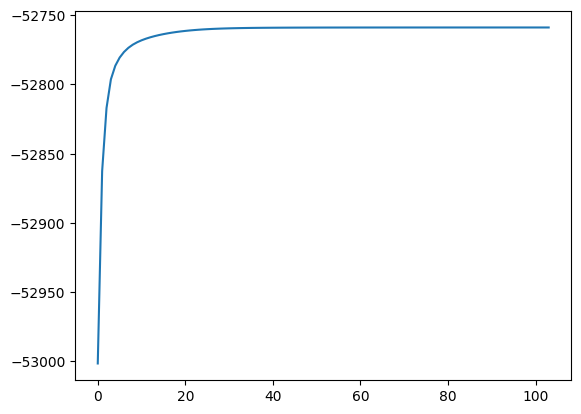

In [18]:
plt.plot(log_likelihoods_setup_1)

In [19]:
date = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

hmm_protein_setup_1.output_model(f"model_protein_dataset_fused_&_downsized_80.0%_{date}.txt")

## Protein Setup Training 2

Using full output of Hobbom

In [20]:
states = 4
alphabet = "ACDEFGHIKLMNPQRSTVWY"

# Path to train file

path_to_train_data = "../../data/train_test_data/hobohm1_ole_formula/default/" + "train_dataset_fused_80.0%.txt"
path_to_empirical_transitions = "../../data/train_test_data/hobohm1_ole_formula/default/" + "empirical_transition_prob"
path_to_empirical_emissions = "../../data/train_test_data/hobohm1_ole_formula/default/" + "empirical_emission_prob"
path_to_empirical_init = "../../data/train_test_data/hobohm1_ole_formula/default/"  + "empirical_init_prob"

sequences, labels, headers = parse_fasta(path_to_train_data, alphabet="ACDEFGHIKLMNPQRSTVWY")
# Take out first residue because is always M
sequences = [seq[1:] for seq in sequences]

Parsed 331 valid sequences


In [21]:
hmm_protein_setup_2 = HMM_efficient(states, alphabet, seed = 1)

In [22]:
pi_empirical = load_empirical_init_prob(path_to_empirical_init, state_order=["I", "M", "O", "S"])

hmm_protein_setup_2.pi = pi_empirical + 1e-3

# normalize
hmm_protein_setup_2.pi /= hmm_protein_setup_2.pi.sum()

State order: ['I', 'M', 'O', 'S']
pi: [0.4773 0.     0.0363 0.4864]


In [23]:
A_empirical, states = load_empirical_transition(path_to_empirical_transitions)
A_smooth = A_empirical + 1e-3
A_smooth /= A_smooth.sum(axis=1, keepdims=True)

hmm_protein_setup_2.A = A_smooth 

States: ['I', 'M', 'O', 'S']
Shape:  (4, 4)
Matrix:
[[0.9963 0.0037 0.     0.    ]
 [0.021  0.9525 0.0265 0.    ]
 [0.     0.0034 0.9966 0.    ]
 [0.     0.     0.0449 0.9551]]


In [24]:
B_empirical, states, amino_acids = load_empirical_emission(path_to_empirical_emissions)

# add pseudocounts to prevent zero emissions and state collapse
pseudocount = 1e-3
B_smooth = B_empirical + pseudocount
B_smooth /= B_smooth.sum(axis=1, keepdims=True)

# assign to model
hmm_protein_setup_2.B = B_smooth

# verify
print(f"Min emission probability: {hmm_protein_setup_2.B.min():.6f}")  # should be > 0
print(f"Row sums: {np.round(hmm_protein_setup_2.B.sum(axis=1), 4)}")   # should be all 1.0

States:      ['I', 'M', 'O', 'S']
Amino acids: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
Shape:       (4, 20)
Min emission probability: 0.009217
Row sums: [1. 1. 1. 1.]


In [25]:
print(f"Initial Probabilities")
print(hmm_protein_setup_2.pi)

print(f"Transition Matrix")
print(hmm_protein_setup_2.A)

print(f"Emission Matrix:")
print(hmm_protein_setup_2.B)

Initial Probabilities
[0.47639442 0.00099602 0.03715139 0.48545817]
Transition Matrix
[[0.99332669 0.00468127 0.00099602 0.00099602]
 [0.02191235 0.9497012  0.02739044 0.00099602]
 [0.00099602 0.00438247 0.9936255  0.00099602]
 [0.00099602 0.00099602 0.04571713 0.95229084]]
Emission Matrix:
[[0.06696735 0.01598196 0.05216198 0.07010491 0.03608197 0.06059418
  0.02519855 0.05245612 0.07657613 0.08245906 0.02902245 0.04824002
  0.04471027 0.04255319 0.06637906 0.07353662 0.05206393 0.06039808
  0.0128444  0.03166977]
 [0.09098931 0.01539367 0.00960879 0.01402098 0.08265516 0.07863516
  0.01294245 0.11050103 0.01402098 0.16864398 0.03892538 0.01431513
  0.02225708 0.01402098 0.01215805 0.042161   0.05265222 0.13109128
  0.03098343 0.04402392]
 [0.06705882 0.04205882 0.05245098 0.05980392 0.03960784 0.075
  0.02382353 0.04431373 0.06411765 0.06911765 0.01872549 0.05098039
  0.0545098  0.0454902  0.05166667 0.07098039 0.0577451  0.06107843
  0.01470588 0.03676471]
 [0.12306335 0.02696607 0.

In [26]:
log_likelihoods_setup_2 = hmm_protein_setup_2.baum_welch(sequences, max_iter=200)

Iteration 1 | log-likelihood: -122273.9451
Iteration 2 | log-likelihood: -122031.3262
Iteration 3 | log-likelihood: -121976.9992
Iteration 4 | log-likelihood: -121948.5511
Iteration 5 | log-likelihood: -121929.1400
Iteration 6 | log-likelihood: -121915.0553
Iteration 7 | log-likelihood: -121904.4491
Iteration 8 | log-likelihood: -121896.2803
Iteration 9 | log-likelihood: -121890.0911
Iteration 10 | log-likelihood: -121885.4456
Iteration 11 | log-likelihood: -121881.9049
Iteration 12 | log-likelihood: -121879.1497
Iteration 13 | log-likelihood: -121876.9719
Iteration 14 | log-likelihood: -121875.2330
Iteration 15 | log-likelihood: -121873.8360
Iteration 16 | log-likelihood: -121872.7097
Iteration 17 | log-likelihood: -121871.8000
Iteration 18 | log-likelihood: -121871.0646
Iteration 19 | log-likelihood: -121870.4696
Iteration 20 | log-likelihood: -121869.9880
Iteration 21 | log-likelihood: -121869.5979
Iteration 22 | log-likelihood: -121869.2814
Iteration 23 | log-likelihood: -121869.02

In [27]:
print("pi:", np.round(hmm_protein_setup_2.pi, 4))

pi: [0.353  0.0285 0.0017 0.6168]


In [28]:
print("A:\n", np.round(hmm_protein_setup_2.A, 2))

A:
 [[0.99 0.01 0.   0.  ]
 [0.02 0.98 0.   0.  ]
 [0.02 0.   0.98 0.  ]
 [0.03 0.   0.03 0.94]]


In [29]:
print("B:\n", np.round(hmm_protein_setup_2.B, 2))

B:
 [[0.07 0.01 0.06 0.08 0.04 0.05 0.02 0.05 0.08 0.09 0.02 0.05 0.04 0.05
  0.06 0.07 0.05 0.06 0.01 0.03]
 [0.09 0.01 0.01 0.01 0.07 0.09 0.02 0.08 0.02 0.14 0.03 0.02 0.04 0.02
  0.03 0.07 0.06 0.11 0.03 0.05]
 [0.06 0.08 0.05 0.04 0.04 0.12 0.02 0.04 0.05 0.04 0.01 0.05 0.06 0.04
  0.05 0.08 0.06 0.05 0.02 0.04]
 [0.13 0.03 0.01 0.01 0.07 0.04 0.01 0.07 0.04 0.2  0.03 0.02 0.02 0.02
  0.03 0.08 0.06 0.12 0.01 0.01]]


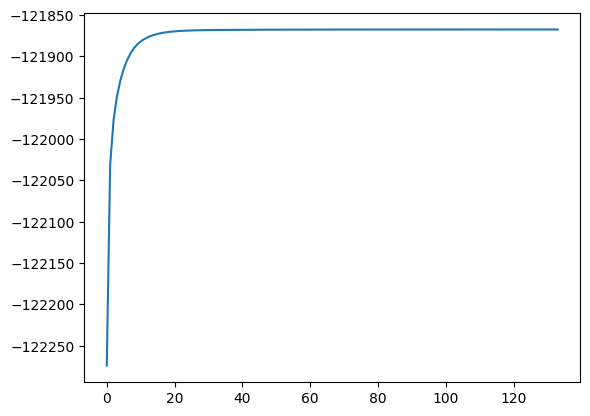

In [30]:
plt.plot(log_likelihoods_setup_2)

In [31]:
date = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

hmm_protein_setup_2.output_model(f"model_protein_dataset_fused_80.0%_{date}.txt")

## Evaluate Performance

This is where Viterbi can come into play!

Viterbi finds the single most likely path through the sequence. It's great for producing a concrete prediction but it's a hard assignment,  every position gets exactly one state with no uncertainty.

Posterior decoding (which you already have via γ\gamma
γ) is often better for evaluation because:

It gives a probability distribution over states at each position
You can threshold or pick the most likely state per position independently
It tends to have higher per-residue accuracy than Viterbi

In [ ]:
"""# flip predicted labels
flipped_labels = [1 - l for l in labels[1]]
cross_entropy, accuracy = hmm_casino.evaluate(sequences[1], flipped_labels)
print(f"acc: {accuracy:.2f}")
print(f"cross entropy: {cross_entropy:.2f}")"""